In [9]:
from scripts.circuit_frame import circuit_frame_evaluation
from circuit_generation import build_ansatz
import matplotlib.pyplot as plt
from numpy import arccos, pi
from frame_potential_gpu import compute_frame_potential_gpu
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


In [10]:
from math import asin, acos
import numpy as np

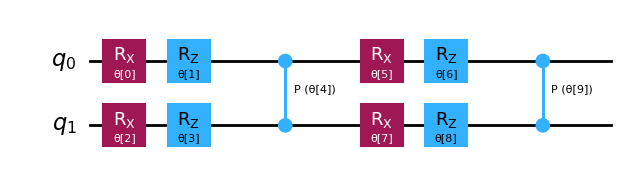

In [11]:
qc = build_ansatz(name="set", n_parameters=8, reps=1,number=3)
qc.draw("mpl")

In [13]:
def parameter_composer(parameters):
    for i in range(len(parameters)):
        if i == 1:
            parameters[i] = acos(parameters[i]/pi - 1)
    return parameters

In [14]:
qc = QuantumCircuit(1)
params = ParameterVector('θ', 5)
qc.rz(params[0], 0)
qc.rx(params[1], 0)
qc.rz(params[2], 0)
F_p = compute_frame_potential_gpu(qc, t=2, n_samples=1000,verbose=False)
print("Frame potential (without parameter composer):", F_p["frame_potential"])
F_p = compute_frame_potential_gpu(qc, t=2, n_samples=1000, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (with parameter composer):", F_p["frame_potential"])
F_p_3 = compute_frame_potential_gpu(qc, t=3, n_samples=100, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=3 with parameter composer):", F_p_3["frame_potential"])                                                                                                                                                                                                                                                                                                                                                                                                                          

F_p_4 = compute_frame_potential_gpu(qc, t=4, n_samples=100, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=4 with parameter composer):", F_p_4["frame_potential"])  

F_p_5 = compute_frame_potential_gpu(qc, t=5, n_samples=100, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=5 with parameter composer):", F_p_5["frame_potential"])




/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:227: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(


Frame potential (without parameter composer): 2.060086488723755
Frame potential (with parameter composer): 1.996718406677246
Frame potential (t=3 with parameter composer): 5.005985260009766
Frame potential (t=4 with parameter composer): 14.641212463378906
Frame potential (t=5 with parameter composer): 40.001590728759766


/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=6: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")
/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=8: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")
/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=10: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")


Composition liste for perfect_SU4 ansatz: ['identity', 'acos', 'identity', 'identity', 'acos', 'identity', 'identity', 'identity', 'identity', 'identity', 'acos', 'identity', 'identity', 'acos', 'identity']


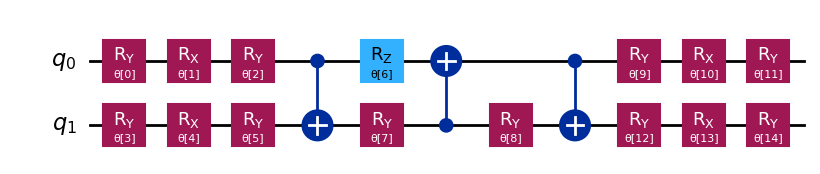

In [7]:
composer_liste = []
qc_su4 = build_ansatz(name="perfect_SU4", n_parameters=15, reps=0, parameter_prefix="θ", composition_liste=composer_liste)
print("Composition liste for perfect_SU4 ansatz:", composer_liste)
qc_su4.draw("mpl")

In [8]:
def parameter_composer_su4(theta):
    for t in range(len(theta)):
        if t in [1,4,10,13,6,7,8]:
            theta[t] = acos(theta[t]/np.pi-1)

In [9]:

F_p = compute_frame_potential_gpu(qc_su4, t=2, n_samples=1000,verbose=False)
print("Frame potential (without parameter composer):", F_p["frame_potential"])
F_p = compute_frame_potential_gpu(qc_su4, t=2, n_samples=1000, parameter_composer=parameter_composer_su4, verbose=False)
print("Frame potential (with parameter composer):", F_p["frame_potential"])

Frame potential (without parameter composer): 2.14860463142395
Frame potential (with parameter composer): 2.02264142036438


In [16]:
from circuit_generation import perfectSU4_anzatz

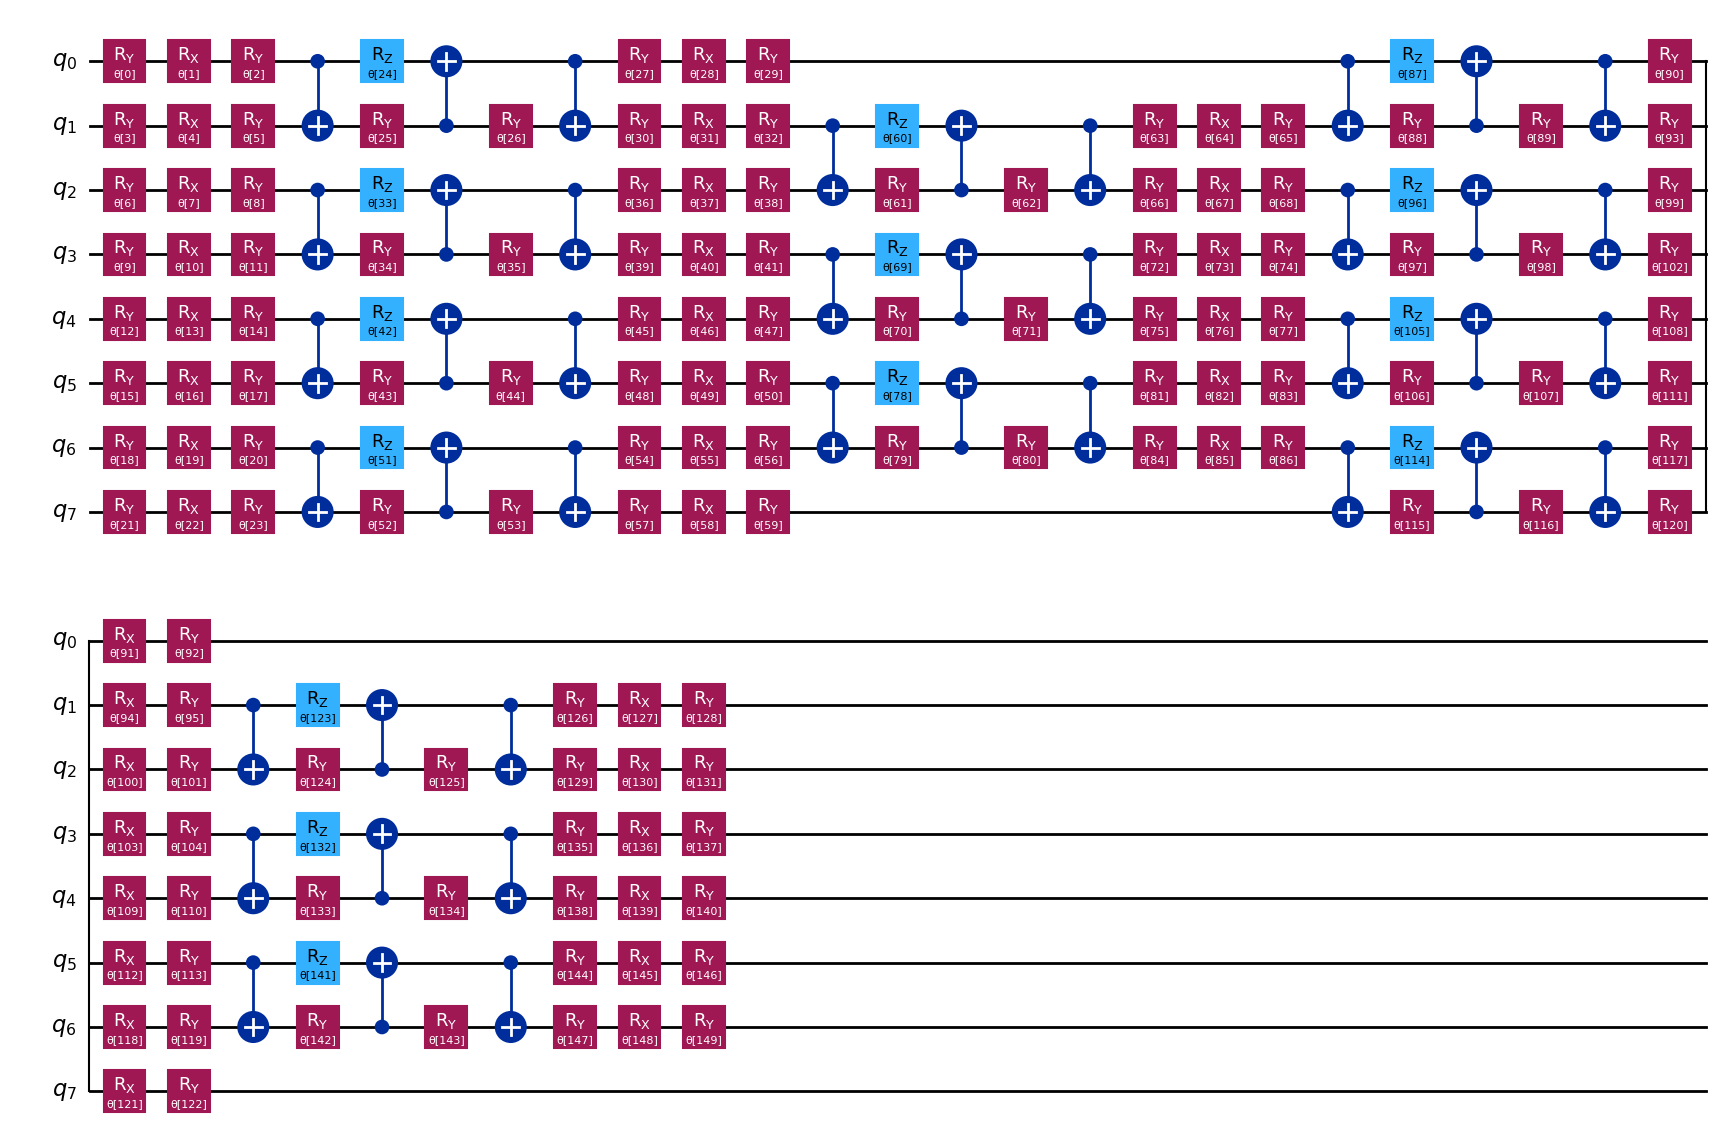

In [19]:
acos_list = []
qc_SU4_8qubits = perfectSU4_anzatz(n_qubits=8,reps=1, parameter_prefix="θ", acos_list=acos_list)
qc_SU4_8qubits.draw("mpl")

In [20]:
def parameter_composer_8qubits(theta):
    for i in acos_list:
        theta[i] = acos(theta[i]/np.pi-1)

In [22]:

F_p = compute_frame_potential_gpu(qc_SU4_8qubits, t=2, n_samples=1000,verbose=False)
print("Frame potential (without parameter composer):", F_p["frame_potential"])
F_p = compute_frame_potential_gpu(qc_SU4_8qubits, t=2, n_samples=1000, parameter_composer=parameter_composer_8qubits, verbose=False)
print("Frame potential (with parameter composer):", F_p["frame_potential"])

/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:227: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(


Frame potential (without parameter composer): 2.3321423530578613
Frame potential (with parameter composer): 2.3071401119232178


In [1]:
from save_read_results import build_result_table
import numpy as np

In [2]:
L,var = build_result_table(path="data/results/classifier_results")
